### Clone repo VMamba from github

In [1]:
!git clone https://github.com/MzeroMiko/VMamba.git

Cloning into 'VMamba'...
remote: Enumerating objects: 8889, done.
remote: Counting objects: 100% (1488/1488), done.
remote: Compressing objects: 100% (244/244), done.
remote: Total 8889 (delta 1351), reused 1320 (delta 1239), pack-reused 7401 (from 1)
Receiving objects: 100% (8889/8889), 34.80 MiB | 30.33 MiB/s, done.
Resolving deltas: 100% (5474/5474), done.


In [2]:
%cd VMamba/

/content/VMamba


In [3]:
%ls

analyze/  checks.sh        detection/  LICENSE       README.md         segmentation/
assets/   classification/  kernels/    modelcard.sh  requirements.txt


In [4]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 8.0 MB/s eta 0:00:00
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61396 sha256=f495f2abb0390496ac6d4017a28058f023f58b157f1757d9e4d75d8c1ba60ef5
  Stored in directory: /root/.cache/pip/wheels/01/c0/af/77c1cf53a1be9e42a52b48e5af2169d40ec2e89f7362489dd0
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31528 sha256=960b8739dffe3eee64fc417d448b8fd89b29792e1fa114f0a85f8ca1e7288538
  Stored in directo

### Optional

In [5]:
!pip install -q mamba-ssm
!pip install -q mamba-ssm[causal-conv1d]
!pip install -q mamba-ssm[dev]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 6.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done


In [6]:
%ls

analyze/  checks.sh        detection/  LICENSE       README.md         segmentation/
assets/   classification/  kernels/    modelcard.sh  requirements.txt


### Install mamba selective scan

In [7]:
%cd kernels/selective_scan/

/content/VMamba/kernels/selective_scan


In [8]:
!pip install -q .

  Preparing metadata (setup.py) ... done


## Load dataset

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.v2 as transforms
import torchvision.datasets as datasets
from tqdm import tqdm
# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [10]:
mean, std = [0.4914, 0.4821, 0.4465], [0.2471, 0.2435, 0.2616]

transform_train = transforms.Compose([
transforms.RandomCrop(32, padding=2),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,
                         std=std),
    transforms.RandomErasing(p=0.75,
                             scale=(0.01, 0.3),
                             ratio=(1.0, 1.0),
                             value=0,
                             inplace =True)])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

/usr/local/lib/python3.10/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [33]:
trainset = datasets.CIFAR10(root='~/data', train=True, download=True,
                            transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=256,
                                          shuffle=True, num_workers=10)

testset = datasets.CIFAR10(root='~/data', train=False, download=True,
                           transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=256,
                                         shuffle=False, num_workers=10)

Files already downloaded and verified


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Files already downloaded and verified


In [12]:
%ls

build/  README.md                 setup.py                     test_selective_scan.py
csrc/   selective_scan.egg-info/  test_selective_scan_easy.py  test_selective_scan_speed.py


In [14]:
%cd /content/VMamba/classification

/content/VMamba/classification


In [34]:
from models.vmamba import VSSM
from typing import OrderedDict
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms


### Define VMamba model

In [42]:
num_classes = 10

model = VSSM(
    depths=[2, 2, 8, 2], dims=96, drop_path_rate=0.2,
    patch_size=4, in_chans=3, num_classes=num_classes, channel_first = True,
    ssm_d_state=1, ssm_ratio=1.0, ssm_dt_rank="auto", ssm_act_layer="silu",
    ssm_conv=3, ssm_conv_bias=False, ssm_drop_rate=0.0,
    ssm_init="v0", forward_type="v05_noz",
    mlp_ratio=4.0, mlp_act_layer="gelu", mlp_drop_rate=0.0, gmlp=False,
    patch_norm=True, norm_layer="ln2d",
    downsample_version="v3", patchembed_version="v2",
    use_checkpoint=False, posembed=False, imgsize=32
)

In [43]:
# path_pretrain = '/home/s12-1/Desktop/Nguyen/data/mendeley_lbc/pretrain_vmamba/vssm1_tiny_0230s_ckpt_epoch_264(1).pth'
path_pretrain = '/content/vssm1_tiny_0230s_ckpt_epoch_264.pth'
checkpoint = torch.load(path_pretrain)

checkpoint_state_dict = checkpoint['model']
current_model_state_dict = model.state_dict()
# Create a new state dictionary by comparing the sizes of tensors
new_state_dict = {}
for k, v in current_model_state_dict.items():
    if k in checkpoint_state_dict and v.size() == checkpoint_state_dict[k].size():
        new_state_dict[k] = checkpoint_state_dict[k]
    else:
        new_state_dict[k] = v
# Load the new state dictionary into the model
msg = model.load_state_dict(new_state_dict, strict=False)
print(msg)


<ipython-input-43-f08c9697db14>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path_pretrain)


<All keys matched successfully>


In [44]:
model.to(device)

VSSM(
  (patch_embed): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Identity()
    (2): LayerNorm2d((48,), eps=1e-05, elementwise_affine=True)
    (3): Identity()
    (4): GELU(approximate='none')
    (5): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (6): Identity()
    (7): LayerNorm2d((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): ModuleList(
    (0): Sequential(
      (blocks): Sequential(
        (0): VSSBlock(
          (norm): LayerNorm2d((96,), eps=1e-05, elementwise_affine=True)
          (op): SS2D(
            (out_norm): LayerNorm2d((96,), eps=1e-05, elementwise_affine=True)
            (in_proj): Linear2d(in_features=96, out_features=96, bias=False)
            (act): SiLU()
            (conv2d): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=96, bias=False)
            (out_act): Identity()
            (out_proj): Linear2d(in_features=96, out_features=96, bias=F

In [45]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params = model.parameters(), lr = 1e-4)

In [47]:
# Function to compute loss and accuracy for test set
def evaluate(model, testloader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(testloader):
            # Move inputs and labels to the device
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_loss = test_loss / len(testloader)
    return test_loss, accuracy

In [48]:
# some parameter
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
max_epoch = 100

In [49]:
# train
for epoch in range(max_epoch):
    running_loss = 0.0
    running_correct = 0   # to track number of correct predictions
    total = 0             # to track total number of samples

    # batch-size = 128
    for i, (inputs, labels) in tqdm(enumerate(trainloader, 0)):
        # Move inputs and labels to the device
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        # Determine class predictions and track accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        running_correct += (predicted == labels).sum().item()

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

    epoch_accuracy = 100 * running_correct / total
    epoch_loss = running_loss / (i + 1)
    test_loss, test_accuracy = evaluate(model, testloader, criterion)
    print(f"Epoch [{epoch + 1}/{max_epoch}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

    # save for plot
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
196it [01:29,  2.20it/s]
100%|██████████| 40/40 [00:07<00:00,  5.38it/s]

Epoch [1/100], Loss: 0.8992, Accuracy: 68.16%, Test Loss: 0.4250, Test Accuracy: 85.00%



196it [01:27,  2.24it/s]
100%|██████████| 40/40 [00:07<00:00,  5.42it/s]

Epoch [2/100], Loss: 0.4769, Accuracy: 83.34%, Test Loss: 0.3302, Test Accuracy: 88.61%



196it [01:27,  2.23it/s]
100%|██████████| 40/40 [00:07<00:00,  5.11it/s]

...

Epoch [37/100], Loss: 0.0535, Accuracy: 98.20%, Test Loss: 0.3392, Test Accuracy: 91.96%



196it [01:27,  2.25it/s]
100%|██████████| 40/40 [00:08<00:00,  5.00it/s]

Epoch [38/100], Loss: 0.0515, Accuracy: 98.26%, Test Loss: 0.3575, Test Accuracy: 92.02%



55it [00:26,  2.05it/s]
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bfffc802b90>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1568, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.10/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/usr/lib/python3.10/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
  File "/usr/lib/python3.10/multiprocessing/connection.py", line 931, in wait
    ready = selector.select(timeout)
  File "/usr/lib/python3.10/selectors.py", line 416, in select
    fd_event_list = self._selector.poll(timeout)
KeyboardInterrupt: 


KeyboardInterrupt: 

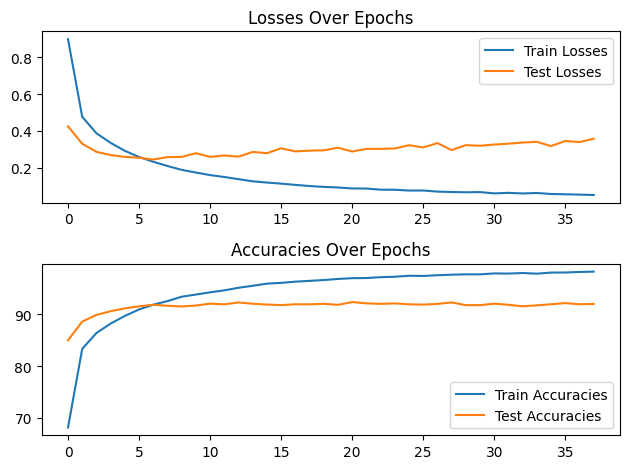

In [50]:
import matplotlib.pyplot as plt

# Create subplots
plt.subplot(2, 1, 1)  # First subplot
plt.plot(train_losses, label='Train Losses')
plt.plot(test_losses, label='Test Losses')
plt.legend()
plt.title('Losses Over Epochs')

plt.subplot(2, 1, 2)  # Second subplot
plt.plot(train_accuracies, label='Train Accuracies')
plt.plot(test_accuracies, label='Test Accuracies')
plt.legend()
plt.title('Accuracies Over Epochs')

# Show the plot
plt.tight_layout()
plt.show()